## --- Generate text with a recurrent neural network (Pytorch) ---
### (Mostly Read & Run)

The goal is to replicate the (famous) experiment from [Karpathy's blog](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)

To learn to generate text, we train a recurrent neural network to do the following task:

Given a "chunk" of text: `this is random text`

the goal of the network is to predict each character in **`his is random text` ** sequentially given the following sequential input **`this is random tex`**:




## Load text (dataset/input.txt)

Before building training batch, we load the full text in RAM

In [1]:
# !wget https://thome.isir.upmc.fr/classes/RITAL/input.txt

In [2]:
#! pip install unidecode

In [3]:
import unidecode
import string
import random
import re
import torch
import torch.nn as nn

all_characters = string.printable
n_characters = len(all_characters)

file = unidecode.unidecode(open("./input.txt").read())  # clean text => only ascii
file_len = len(file)
print("file_len =", file_len)


file_len = 1115394


## 2: Helper functions:

We have a text and we want to feed batch of chunks to a neural network:

one chunk  A,B,C,D,E
[input] A,B,C,D -> B,C,D,E [output]

Note: we will use an embedding layer instead of a one-hot encoding scheme.

for this, we have 3 functions:

- One to get a random str chunk of size `chunk_len` : `random_chunk`
- One to turn a chunk into a tensor of size `(1,chunk_len)` coding for each characters : `char_tensor`
- One to return random input and output chunks of size `(batch_size,chunk_len)` : `random_training_set`




In [4]:
# GPU Support
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
import time, math


# Get a piece of text
def random_chunk(chunk_len):
    start_index = random.randint(0, file_len - chunk_len - 1)  # added the -1
    end_index = start_index + chunk_len + 1
    return file[start_index:end_index]


# Turn string into list of longs
def char_tensor(string):
    tensor = torch.zeros(1, len(string)).long()
    for c in range(len(string)):
        tensor[0, c] = all_characters.index(string[c])
    return tensor


# Turn a piece of text in train/test
def random_training_set(chunk_len=200, batch_size=8):
    chunks = [random_chunk(chunk_len) for _ in range(batch_size)]
    inp = torch.cat([char_tensor(chunk[:-1]) for chunk in chunks], dim=0)
    target = torch.cat([char_tensor(chunk[1:]) for chunk in chunks], dim=0)

    return inp.to(device), target.to(device)


print(random_training_set(10, 4))  ## should return 8 chunks of 10 letters.

(tensor([[27, 23, 68, 13, 94, 22, 14, 94, 29, 24],
        [10, 29, 18, 28, 15, 18, 14, 13, 78, 96],
        [24, 27, 28, 24, 24, 20, 94, 17, 18, 28],
        [30, 29, 94, 29, 24, 94, 13, 14, 10, 29]], device='cuda:0'), tensor([[23, 68, 13, 94, 22, 14, 94, 29, 24, 82],
        [29, 18, 28, 15, 18, 14, 13, 78, 96, 38],
        [27, 28, 24, 24, 20, 94, 17, 18, 28, 94],
        [29, 94, 29, 24, 94, 13, 14, 10, 29, 17]], device='cuda:0'))


## The actual RNN model (only thing to complete):

It should be composed of three distinct modules:

- an [embedding layer](https://pytorch.org/docs/stable/nn.html#embedding) (n_characters, hidden_size)

```
nn.Embedding(len_dic,size_vec)
```
- a [recurrent](https://pytorch.org/docs/stable/nn.html#recurrent-layers) layer (hidden_size, hidden_size)
```
nn.RNN(in_size,out_size) or nn.GRU() or nn.LSTM() => rnn_cell parameter
```
- a [prediction](https://pytorch.org/docs/stable/nn.html#linear) layer (hidden_size, output_size)

```
nn.Linear(in_size,out_size)
```
=> Complete the `init` function code

In [6]:
import torch.nn.functional as f


class RNN(nn.Module):
    def __init__(self, n_char, hidden_size, output_size, n_layers=1, rnn_cell=nn.RNN):
        """
        Create the network
        """
        super(RNN, self).__init__()

        self.n_char = n_char
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers

        #  (batch,chunk_len) -> (batch, chunk_len, hidden_size)
        self.embed = nn.Embedding(n_char, hidden_size)

        # (batch, chunk_len, hidden_size)  -> (batch, chunk_len, hidden_size)
        self.rnn = rnn_cell(hidden_size, hidden_size)

        # (batch, chunk_len, hidden_size) -> (batch, chunk_len, output_size)
        self.predict = nn.Linear(hidden_size, output_size)

    def forward(self, input):
        """
        batched forward: input is (batch > 1,chunk_len)
        """
        input = self.embed(input)
        output, _ = self.rnn(input)
        output = self.predict(f.tanh(output))
        return output

    def forward_seq(self, input, hidden=None):
        """
        not batched forward: input is  (1,chunk_len)
        """
        input = self.embed(input)
        output, hidden = self.rnn(input.unsqueeze(0), hidden)
        output = self.predict(f.tanh(output))
        return output, hidden

## Text generation function

Sample text from the model

In [7]:
def generate(model, prime_str="A", predict_len=100, temperature=0.8):
    prime_input = char_tensor(prime_str).squeeze(0).to(device)
    hidden = None
    predicted = prime_str + ""
    # Use priming string to "build up" hidden state

    for p in range(len(prime_str) - 1):
        _, hidden = model.forward_seq(prime_input[p].unsqueeze(0), hidden)

    # print(hidden.size())
    for p in range(predict_len):
        output, hidden = model.forward_seq(prime_input[-1].unsqueeze(0), hidden)
        # Sample from the network as a multinomial distribution
        output_dist = output.data.view(-1).div(temperature).exp()
        # print(output_dist)
        top_i = torch.multinomial(output_dist, 1)[0]
        # print(top_i)
        # Add predicted character to string and use as next input
        predicted_char = all_characters[top_i]
        predicted += predicted_char
        prime_input = torch.cat(
            [prime_input, char_tensor(predicted_char).squeeze(0).to(device)]
        ).to(device)

    return predicted


## Training loop for net

In [8]:
def time_since(since):
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
    return "%dm %ds" % (m, s)


###Parameters
n_epochs = 20000
print_every = 100
plot_every = 10
hidden_size = 100
n_layers = 5
lr = 0.005
batch_size = 16
chunk_len = 80

####

model = RNN(n_characters, hidden_size, n_characters, n_layers).to(
    device
)  # create model
model_optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # create Adam optimizer
criterion = nn.CrossEntropyLoss()  # chose criterion

start = time.time()
all_losses = []
loss_avg = 0


def train(inp, target):
    """
    Train sequence for one chunk:
    """
    # move to device
    inp = inp.to(device)
    target = target.to(device)

    # reset gradients
    model_optimizer.zero_grad()

    # predict output
    output = model(inp)

    # compute loss
    loss = criterion(output.view(batch_size * chunk_len, -1), target.view(-1))

    # compute gradients and backpropagate
    loss.backward()
    model_optimizer.step()

    return loss.data.item()


for epoch in range(1, n_epochs + 1):
    loss = train(*random_training_set(chunk_len, batch_size))  # train on one chunk
    loss_avg += loss

    if epoch % print_every == 0:
        print(
            "[%s (%d %d%%) %.4f]"
            % (time_since(start), epoch, epoch / n_epochs * 100, loss)
        )
        print(generate(model, "Wh", 100), "\n")

    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0

 2s (100 0%) 2.5115]
Whesse:
Le:
IUERD
Seare he sin fot t f kele me, atharamersusows hat fe than gand wthelerte I d ise, fo 

 4s (200 1%) 2.4695]
Whe skesthe.
ARy s acowhy ancond aif s yort I do, CHAeand!
HARDUDIARI:
Prd me athe; our f, wimanord l  

 7s (300 1%) 2.5359]
Whire f.
I tia s wigspatherr thias d r hase lad
Jur he te me ave myorn t harithad he thar, warr dars s 

 9s (400 2%) 2.4924]
Whed
I ck meel.
Nourf atond thear ooupather acr f ath K:
That mico ons l s w ge e ie, d y sho the sllo 

 11s (500 2%) 2.5130]
Whithis bboratid but t chith blepl ive ine bofat haghar pr therando tho.

I me o'st some s n the astha 

 14s (600 3%) 2.5061]
Whamaceaighes witherst LI s be'd tollatl ingofr I baberoritaro or, con ghamat hea LI hane tofiris y ts 

 16s (700 3%) 2.4622]
Whorst moun w t ng pe


TENGRCos, we heapothel hestave g aldve:
The t at the lan thomesin ave hely ire 

 19s (800 4%) 2.5163]
Whe tothe t hir Mease wrn tound, fe is, merorusthalold knke by arit mue akilllot t onothoiean

## Visualize loss

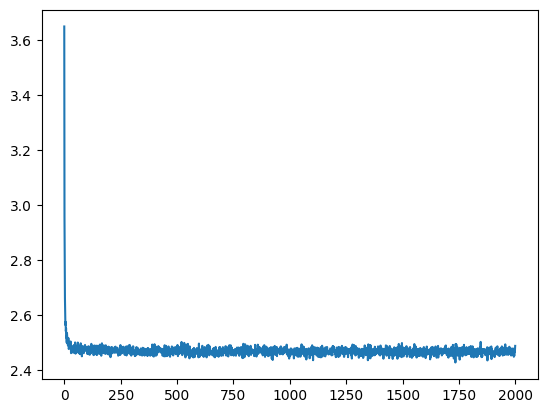

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

%matplotlib inline

plt.figure()
plt.plot(all_losses)
plt.show()

## Try different temperatures

Changing the distribution sharpness has an impact on character sampling:

more or less probable things are sampled

In [10]:
print(generate(model, "T", 200, temperature=1))
print("----")
print(generate(model, "Th", 200, temperature=0.8))
print("----")

print(generate(model, "Th", 200, temperature=0.5))
print("----")

print(generate(model, "Th", 200, temperature=0.3))
print("----")

print(generate(model, "Th", 200, temperature=0.1))

THA ad pllaweather fan:

D oo guifies; ossin; at:
Roure omeavitheles otandud eeard, ke.
If moucovise rute herun y meaterssoltcrt wiraiare it t gnd fth stheeltwinthee fo y, thit ffore ang'sod ad lan ha 
----
Thare che ou argu oowave t ke ly; aliner anors I in tusere nd hirat te foorethavind ce.
IUMEROLO:
I hofe e; my thapoor yosste and t alas s l brd is, wim an feind ano l sws mere oube'd trcrveyanindious y
----
The and gho bele thin he shat, thall t atheson me are anore bere lire profond t t s ay handou thaned f le at thad bed ce y g, he he at whe ithes the thand at and me and.
The me the t wond t matoureres t
----
The thour athe and t m t thenoure the the mer he he the the the the te he the te the he ther me be the the ar wed the he he hand and he the t alllll ce me ures me the the ane t he thathes heane hand fou
----
The the the the the the the the the the the the the the the the the the the the athe the the the the the the the the the the the the the the the the the the the he the t

### Improving this code:

(a) Tinker with parameters:

- Is it really necessary to have 100 dims character embeddings
- Chunk length can be gradually increased
- Try changing RNN cell type (GRUs - LSTMs)

(b) Add GPU support to go faster
